In [43]:
import pandas as pd                     # работа с табличными данными
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
from io import StringIO, BytesIO
import joblib

# import boto3
# import mlflow
# import mlflow.sklearn

# print(pd.__version__)

In [20]:
df = pd.read_csv('../data/input_data/car data.csv')
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [21]:
# EDA и Preprocessing
df = df.dropna(subset=['Selling_Price']) # Удаляем строки, где цена отсутствует
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [22]:
# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Определяем числовые и категориальные колонки
numeric_features = ['Year', 'Kms_Driven']
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

In [24]:
# Создаем преобразователи
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
# Объединяем преобразователи
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [26]:
# Обучение модели
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [ ]:
# Проверка данных после преобразований


# Применим preprocessor к небольшим данным, чтобы увидеть результат
X_sample = X_train.head(5)
preprocessed_sample = preprocessor.fit_transform(X_sample)

# Получим имена фичей после OneHotEncoder
# Это немного сложно, но очень полезно для понимания
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

# Создадим DataFrame с преобразованными данными
preprocessed_df = pd.DataFrame(preprocessed_sample.toarray() if hasattr(preprocessed_sample, 'toarray') else preprocessed_sample, 
                              columns=all_feature_names)

print("Исходные данные:")
display(X_sample)
print("\nПосле преобразований:")
display(preprocessed_df)

Исходные данные:


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
184,Bajaj Pulsar 150,2008,0.750,26000,Petrol,Individual,Manual,1
132,Bajaj Avenger 220,2017,0.950,3500,Petrol,Individual,Manual,0
194,Hero CBZ Xtreme,2008,0.787,50000,Petrol,Individual,Manual,0
75,etios g,2015,6.800,36000,Petrol,Dealer,Manual,0
111,Royal Enfield Thunder 350,2016,1.500,8700,Petrol,Individual,Manual,0



После преобразований:


,Year,Kms_Driven,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Manual,Owner_0,Owner_1
0,-1.209103,0.067542,1.0,0.0,1.0,1.0,0.0,1.0
1,1.057965,-1.242542,1.0,0.0,1.0,1.0,1.0,0.0
2,-1.209103,1.464965,1.0,0.0,1.0,1.0,1.0,0.0
3,0.554172,0.649802,1.0,1.0,0.0,1.0,1.0,0.0
4,0.806068,-0.939767,1.0,0.0,1.0,1.0,1.0,0.0


In [30]:
# Проверка качества модели на кросс-валидации

# Кросс-валидация
cv_scores = cross_val_score(model, X_train, y_train, 
                           cv=5, scoring='neg_root_mean_squared_error')

print("RMSE на кросс-валидации:")
print(f"Среднее: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")
print("Все значения:", -cv_scores)

RMSE на кросс-валидации:
Среднее: 3.34 ± 0.82
Все значения: [3.65263793 4.67638565 2.3500673  3.35458494 2.66156023]


Метрики на тестовой выборке:
RMSE: 2.02
MAE: 1.21
R²: 0.823


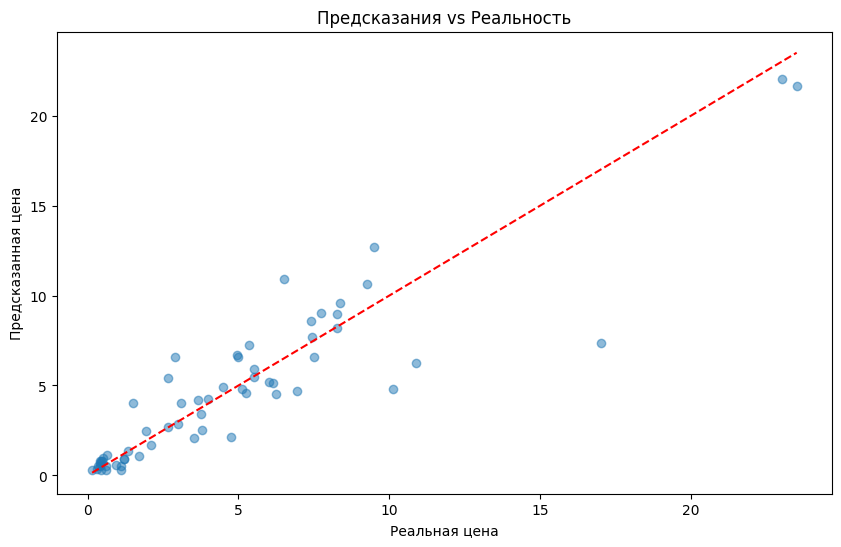

In [35]:
# Обучение и оценка на тестовой выборке

# Обучаем модель на всей тренировочной выборке
model.fit(X_train, y_train)

# Предсказания и оценка
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("Метрики на тестовой выборке:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.3f}")

# Визуализация предсказаний vs реальные значения

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Предсказания vs Реальность')
plt.show()

Важность признаков:
Количество признаков: 12
Количество важностей: 12


,feature,importance
3,Fuel_Type_Diesel,0.250250
1,Kms_Driven,0.214974
5,Seller_Type_Dealer,0.116317
8,Transmission_Manual,0.104909
0,Year,0.104757
6,Seller_Type_Individual,0.097162
7,Transmission_Automatic,0.084207
4,Fuel_Type_Petrol,0.025446
10,Owner_1,0.000647
9,Owner_0,0.000564


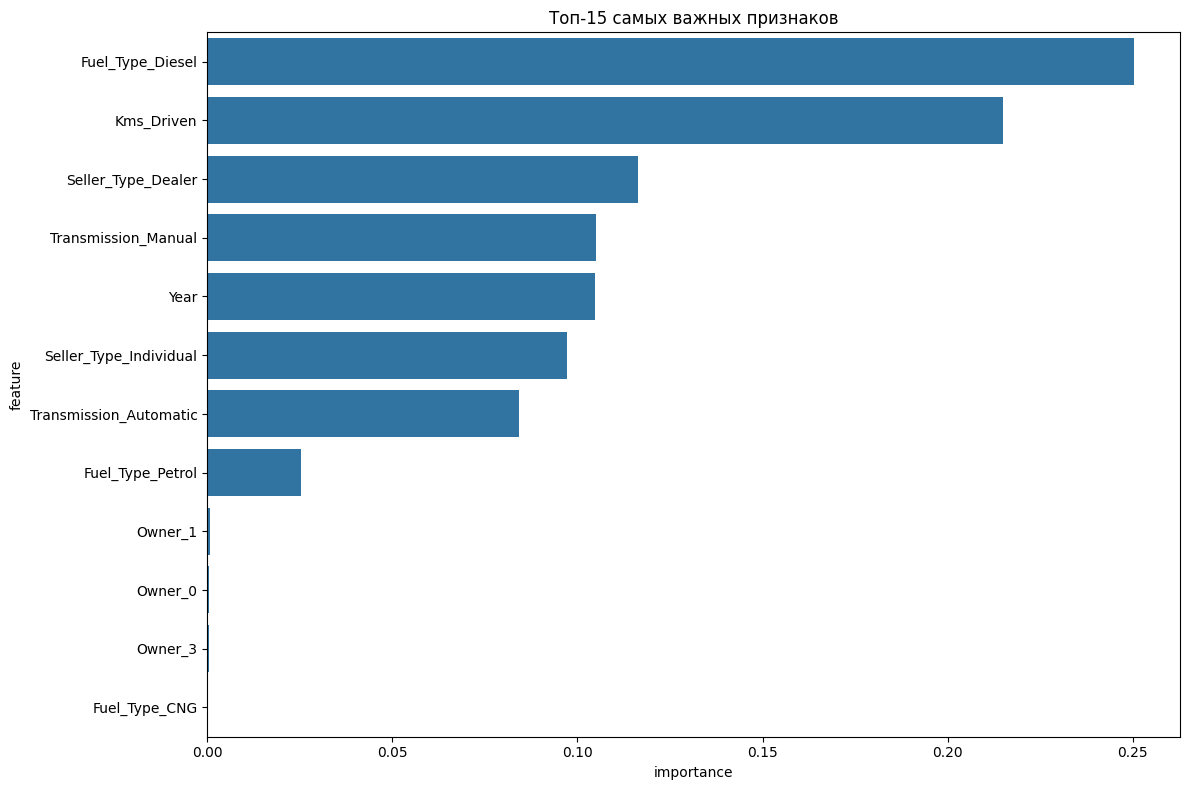

In [37]:
# Анализ важности признаков

# Получаем обученный RandomForest из пайплайна
rf_model = model.named_steps['regressor']

# Получаем preprocessing часть из пайплайна
preprocessor = model.named_steps['preprocessor']

# Получаем имена признаков после всех преобразований
# Для числовых признаков - просто их имена
numeric_features = preprocessor.transformers_[0][2]  # ['year', 'km_driven']

# Для категориальных - получаем имена из OneHotEncoder
cat_transformer = preprocessor.named_transformers_['cat']
cat_encoder = cat_transformer.named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Объединяем все имена признаков
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

# Получаем важность признаков
feature_importances = rf_model.feature_importances_

# Создаем DataFrame для наглядности
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("Важность признаков:")
print(f"Количество признаков: {len(all_feature_names)}")
print(f"Количество важностей: {len(feature_importances)}")
display(importance_df.head(10))

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(15))
plt.title('Топ-15 самых важных признаков')
plt.tight_layout()
plt.show()

In [38]:
# Проверка на отдельных примерах


# Возьмем несколько случайных примеров из тестовой выборки
sample_indices = np.random.choice(X_test.index, 5, replace=False)
sample_data = X_test.loc[sample_indices]
actual_prices = y_test.loc[sample_indices]

# Предсказания
predicted_prices = model.predict(sample_data)

# Сравнение
comparison = pd.DataFrame({
    'Реальная цена': actual_prices.values,
    'Предсказанная цена': predicted_prices,
    'Ошибка (%)': np.abs((predicted_prices - actual_prices.values) / actual_prices.values * 100)
})

print("Предсказания для отдельных примеров:")
display(comparison)

Предсказания для отдельных примеров:


,Реальная цена,Предсказанная цена,Ошибка (%)
0,8.25,8.223000,0.327273
1,3.00,2.883500,3.883333
2,6.00,5.207839,13.202679
3,0.40,0.685500,71.375000
4,1.10,0.303300,72.427273


In [41]:
# Проверка обработки пропущенных значений


# Создадим тестовые данные с пропусками
test_data_with_nan = X_train.head(3).copy()
test_data_with_nan.loc[test_data_with_nan.index[0], 'Year1'] = np.nan
test_data_with_nan.loc[test_data_with_nan.index[1], 'Fuel_Type1'] = np.nan

print("Тестовые данные с пропусками:")
display(test_data_with_nan)

# Проверим, что пайплайн корректно обрабатывает их
try:
    predictions = model.predict(test_data_with_nan)
    print("Предсказания для данных с пропусками:", predictions)
    print("✅ Пайплайн корректно обрабатывает пропущенные значения!")
except Exception as e:
    print("❌ Ошибка:", e)

Тестовые данные с пропусками:


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Year1,Fuel_Type1
184,Bajaj Pulsar 150,2008,0.750,26000,Petrol,Individual,Manual,1,NaN,NaN
132,Bajaj Avenger 220,2017,0.950,3500,Petrol,Individual,Manual,0,NaN,NaN
194,Hero CBZ Xtreme,2008,0.787,50000,Petrol,Individual,Manual,0,NaN,NaN


Предсказания для данных с пропусками: [0.2623 0.8602 0.1972]
✅ Пайплайн корректно обрабатывает пропущенные значения!


In [44]:
# Сохранение и загрузка модели

# Тестируем сохранение и загрузку
# Сохраняем
joblib.dump(model, '../data/output_data/test_model.joblib')

# Загружаем
loaded_model = joblib.load('../data/output_data/test_model.joblib')

# Сравниваем предсказания
original_pred = model.predict(X_test.head(3))
loaded_pred = loaded_model.predict(X_test.head(3))

print("Предсказания оригинальной модели:", original_pred)
print("Предсказания загруженной модели:", loaded_pred)
print("Предсказания идентичны:", np.allclose(original_pred, loaded_pred))

Предсказания оригинальной модели: [0.527  4.7915 6.684 ]
Предсказания загруженной модели: [0.527  4.7915 6.684 ]
Предсказания идентичны: True


In [45]:
# Финальная проверка всего пайплайна

# Имитация полного цикла на маленьком наборе данных
# Маленький subset для быстрой проверки
X_small, _, y_small, _ = train_test_split(X, y, train_size=0.1, random_state=42)

# Быстрое обучение с меньшим числом деревьев
test_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=10, random_state=42))
])

test_model.fit(X_small, y_small)
score = test_model.score(X_small, y_small)
print(f"R² score на маленьком наборе: {score:.3f}")
print("✅ Весь пайплайн работает корректно!")

R² score на маленьком наборе: 0.874
✅ Весь пайплайн работает корректно!
